Data Cleaning

In [7]:
import pandas as pd
df = pd.read_csv('../data/raw/telemetry.csv', parse_dates=['eventDateTime'])
df.head()

,Unnamed: 0,vehicleId,eventDateTime,gpsLatitude,gpslongitude,gpsAltitude_Last,gpsAltitude_First,speed,Coasting,Coasting_iso,RashTurning,Idling,OverSpeeding,HarshAcceleration,HarshBrake,eventdate
0,0,MAT790205M7C08185,2023-09-10 09:50:00,28.869072,75.917158,19298,19305,0.000000,0,0,0,0,0,0,0,2023-09-10
1,1,MAT819003M1A01810,2023-09-10 13:50:00,27.761594,77.472051,18321,18483,0.000000,0,0,0,0,0,0,0,2023-09-10
2,2,MAT819003M1A01810,2023-09-10 11:50:00,27.761546,77.472013,17871,17895,0.000000,0,0,0,0,0,0,0,2023-09-10
3,3,MAT790205M7C08185,2023-09-10 16:00:00,29.267018,76.198022,20925,21426,32.903904,0,0,0,0,0,0,0,2023-09-10
4,4,MAT819003M1A01810,2023-09-10 18:20:00,27.761594,77.472070,17911,17908,0.000000,0,0,0,0,0,0,0,2023-09-10


In [8]:
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
Unnamed: 0           0
vehicleId            0
eventDateTime        0
gpsLatitude          0
gpslongitude         0
gpsAltitude_Last     0
gpsAltitude_First    0
speed                0
Coasting             0
Coasting_iso         0
RashTurning          0
Idling               0
OverSpeeding         0
HarshAcceleration    0
HarshBrake           0
eventdate            0
dtype: int64

Duplicate Rows: 0


In [14]:
df = df.sort_values(by=['vehicleId', 'eventDateTime'])
df.head()

,Unnamed: 0,vehicleId,eventDateTime,gpsLatitude,gpslongitude,gpsAltitude_Last,gpsAltitude_First,speed,Coasting,Coasting_iso,RashTurning,Idling,OverSpeeding,HarshAcceleration,HarshBrake,eventdate
45314,45314,MAT447309M2C03408,2023-09-10 05:40:00,30.910218,76.832474,42506,0,0.0,0,0,0,0,0,0,0,2023-09-10
65368,65368,MAT447309M2C03408,2023-09-10 09:10:00,30.910422,76.832224,44550,0,0.0,0,0,0,0,0,0,0,2023-09-10
17194,17194,MAT447309M2C03408,2023-09-10 09:50:00,30.910352,76.832518,43801,42470,0.0,0,0,0,0,0,0,0,2023-09-10
59110,59110,MAT447309M2C03408,2023-09-10 10:00:00,30.910314,76.832518,43572,43694,0.0,0,0,0,3,0,0,0,2023-09-10
46576,46576,MAT447309M2C03408,2023-09-10 10:10:00,30.910326,76.832506,43497,43569,0.0,0,0,0,7,0,0,0,2023-09-10


In [15]:
df['is_stationary'] = df['speed'] == 0
print(df.head())

       Unnamed: 0          vehicleId       eventDateTime  gpsLatitude  \
45314       45314  MAT447309M2C03408 2023-09-10 05:40:00    30.910218   
65368       65368  MAT447309M2C03408 2023-09-10 09:10:00    30.910422   
17194       17194  MAT447309M2C03408 2023-09-10 09:50:00    30.910352   
59110       59110  MAT447309M2C03408 2023-09-10 10:00:00    30.910314   
46576       46576  MAT447309M2C03408 2023-09-10 10:10:00    30.910326   

       gpslongitude  gpsAltitude_Last  gpsAltitude_First  speed  Coasting  \
45314     76.832474             42506                  0    0.0         0   
65368     76.832224             44550                  0    0.0         0   
17194     76.832518             43801              42470    0.0         0   
59110     76.832518             43572              43694    0.0         0   
46576     76.832506             43497              43569    0.0         0   

       Coasting_iso  RashTurning  Idling  OverSpeeding  HarshAcceleration  \
45314             0  

EDA

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

stats = df.groupby('vehicleId').agg(
    total_records=('eventDateTime', 'count'),
    avg_speed=('speed', 'mean'),
    max_speed=('speed', 'max'),
    harsh_brakes=('HarshBrake', 'sum'),
    harsh_accel=('HarshAcceleration', 'sum'),
    overspeeding=('OverSpeeding', 'sum')
)

print("--- Driver/Vehicle Summary ---")
print(stats.describe())

--- Driver/Vehicle Summary ---
       total_records    avg_speed    max_speed  harsh_brakes  harsh_accel  \
count    1350.000000  1350.000000  1350.000000   1350.000000  1350.000000   
mean       55.234074     9.378256    29.851398      0.002963     1.506667   
std        47.208542     9.262849    21.071521      0.054373     4.290718   
min         1.000000     0.000000     0.000000      0.000000     0.000000   
25%        16.000000     0.545208     6.079239      0.000000     0.000000   
50%        40.000000     7.362427    32.888929      0.000000     0.000000   
75%        91.750000    14.824231    48.454588      0.000000     1.000000   
max       144.000000    45.974460    71.286717      1.000000    65.000000   

       overspeeding  
count   1350.000000  
mean       0.097778  
std        1.982334  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max       68.000000  


C:\Users\JERMAGNE\AppData\Local\Temp\ipykernel_15392\335071728.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['speed'], x=df['HarshAcceleration'], palette='Set2')
C:\Users\JERMAGNE\AppData\Local\Temp\ipykernel_15392\335071728.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['is_risky'], palette='coolwarm')


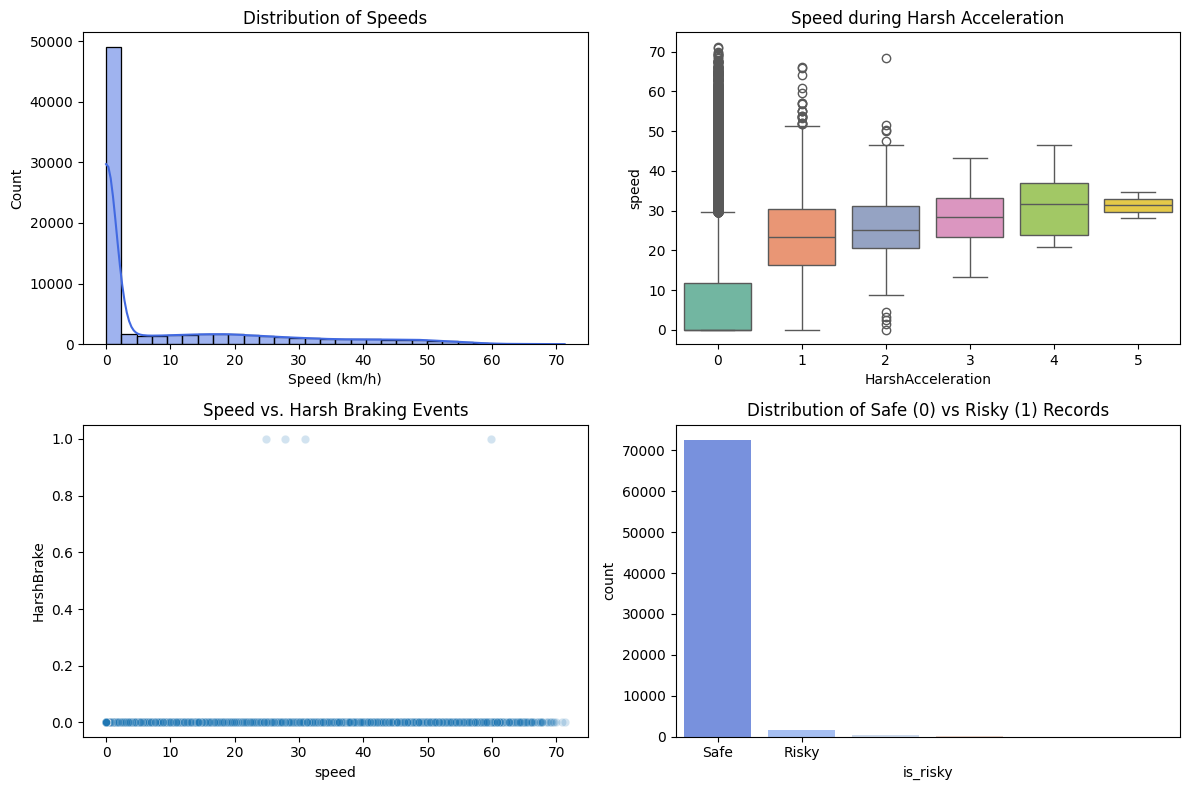

In [17]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['speed'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Speeds')
plt.xlabel('Speed (km/h)')

plt.subplot(2, 2, 2)
sns.boxplot(y=df['speed'], x=df['HarshAcceleration'], palette='Set2')
plt.title('Speed during Harsh Acceleration')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='speed', y='HarshBrake', alpha=0.2)
plt.title('Speed vs. Harsh Braking Events')

df['is_risky'] = df[['HarshBrake', 'HarshAcceleration', 'OverSpeeding', 'RashTurning']].max(axis=1)
plt.subplot(2, 2, 4)
sns.countplot(x=df['is_risky'], palette='coolwarm')
plt.title('Distribution of Safe (0) vs Risky (1) Records')
plt.xticks([0, 1], ['Safe', 'Risky'])

plt.tight_layout()
plt.show()